<a href="https://colab.research.google.com/github/hariharan2302/hariharan2302/blob/main/Assignment_1_checkpoint.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Assignment 1- Defining & Solving RL Environments:**




In [1]:
!pip install gymnasium matplotlib numpy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 5.9 MB/s eta 0:00:00


### **TASK 1**
**1.1.DETERMINISTIC ENVIRONMENT**

In [62]:
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import numpy as np
import time

<ipython-input-63-7b7729b96fec>:23: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axes.scatter(reward_pos_3[1],reward_pos_3[0], marker='x', edgecolors='k', linewidths=3,
<ipython-input-63-7b7729b96fec>:25: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axes.scatter(reward_pos_4[1], reward_pos_4[0], marker='x', edgecolors='k', linewidths=3,


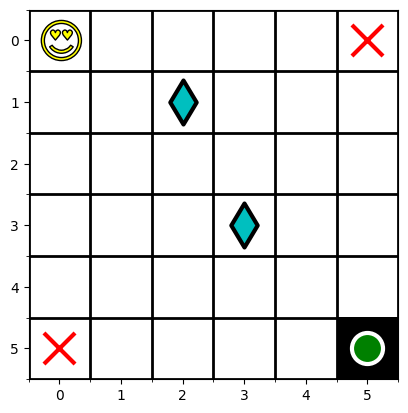

In [63]:
# Prototype of My Environment
my_grid_width = 6
my_grid_height = 6
grid = np.zeros((my_grid_height, my_grid_width))
start_pos = [0, 0]
reward_pos_1 = [3,3]
reward_pos_2 = [1,2]
reward_pos_3 = [5,0]
reward_pos_4 = [0,5]
end_pos = [5, 5]
grid[tuple(start_pos)] = 0
grid[tuple(end_pos)] = 1
figure, axes = plt.subplots()
axes.set_xticks(np.arange(-0.5, my_grid_width, 1), minor=True)
axes.set_yticks(np.arange(-0.5, my_grid_height, 1), minor=True)
axes.grid(which='minor', color='black', linestyle='-', linewidth=2)
axes.imshow(grid, cmap='binary', interpolation='nearest')
axes.scatter(end_pos[1],end_pos[0], marker='o',edgecolors='white',linewidths=3, color='g', s=500, alpha=1)
axes.scatter(reward_pos_1[1], reward_pos_1[0], marker='d', edgecolors='k', linewidths=3,
                   color='c', s=500, alpha=1)
axes.scatter(reward_pos_2[1], reward_pos_2[0], marker='d', edgecolors='k', linewidths=3,
                   color='c', s=500, alpha=1)
axes.scatter(reward_pos_3[1],reward_pos_3[0], marker='x', edgecolors='k', linewidths=3,
                   color='r', s=500, alpha=1)
axes.scatter(reward_pos_4[1], reward_pos_4[0], marker='x', edgecolors='k', linewidths=3,
                   color='r', s=500, alpha=1)
axes.scatter(start_pos[1], start_pos[0], marker='$\U0001F60D$',edgecolors='k',linewidths=1, color='yellow', s=1000, alpha=1)
plt.show()

In [64]:
class Deterministic_Environment(gym.Env):
    metadata = { 'render.modes': [] }
    def __init__(self):
      self.observation_space = spaces.Discrete(36)
      self.action_space = spaces.Discrete(4)
      self.max_timesteps = 15
      self.timestep = 0
      self.agent_pos = [0, 0]
      self.reward_pos_1 = [3,3]
      self.reward_pos_2 = [1,2]
      self.reward_pos_3 = [5,0]
      self.reward_pos_4 = [0,5]
      self.goal_pos = [5, 5]
      self.state = np.zeros((6,6))
      self.state[tuple(self.agent_pos)] = 111
      self.state[tuple(self.goal_pos)] = 888

    def reset(self, **kwargs):
      self.agent_pos = [0, 0]
      self.reward_pos_1 = [3,3]
      self.reward_pos_2 = [1,2]
      self.reward_pos_3 = [5,0]
      self.reward_pos_4 = [0,5]
      self.goal_pos = [5, 5]
      self.state = np.zeros((6,6))
      self.state[tuple(self.agent_pos)] = 111
      self.state[tuple(self.goal_pos)] = 888
      observation = self.state.flatten()
      info = {}
      return observation, info

    def step(self, action):
      if action == 0: #Down
        self.agent_pos[0] += 1
      elif action == 1: #Up
        self.agent_pos[0] -= 1
      elif action == 2: #Right
        self.agent_pos[1] += 1
      elif action == 3: #Left
        self.agent_pos[1] -= 1
      self.agent_pos = np.clip(self.agent_pos, 0, 5)
      self.state = np.zeros((6,6))
      self.state[tuple(self.agent_pos)] = 111
      self.state[tuple(self.goal_pos)] = 888
      print("Current State:", self.state)
      observation = self.state.flatten()
      reward = 0
      if np.array_equal(self.agent_pos, self.goal_pos):
        terminated = True
        reward = 1
      else:
        terminated = False
        reward = 0
      if np.array_equal(self.agent_pos, self.reward_pos_1) or np.array_equal(self.agent_pos, self.reward_pos_2):
        reward = 1
      elif np.array_equal(self.agent_pos, self.reward_pos_3) or np.array_equal(self.agent_pos, self.reward_pos_4):
        reward = -1
      self.timestep += 1
      if self.timestep >= self.max_timesteps:
            terminated = True
      truncated = True if np.all((np.asarray(self.agent_pos) >=0 ) & (np.asarray(self.agent_pos) <= 5)) else False
      return observation, reward, terminated, truncated

    def render(self,agent_actions,ax=None):
      if ax is None:
        fig, ax = plt.subplots()
      my_grid_width = 6
      my_grid_height = 6
      grid = np.zeros((my_grid_height, my_grid_width))
      grid[tuple(self.goal_pos)] = 1
      grid[tuple(self.reward_pos_1)] = 0.5
      grid[tuple(self.reward_pos_2)] = 0.5
      grid[tuple(self.reward_pos_3)] = -0.5
      grid[tuple(self.reward_pos_4)] = -0.5
      for a_position in agent_actions:
        grid[tuple(a_position)] = 0
      ax.set_xticks(np.arange(-0.5, my_grid_width, 1), minor=True)
      ax.set_yticks(np.arange(-0.5, my_grid_height, 1), minor=True)
      ax.grid(which='minor', color='black', linestyle='-', linewidth=2)
      ax.imshow(grid, cmap='binary', interpolation='nearest')
      ax.scatter(self.goal_pos[1], self.goal_pos[0], marker='o',edgecolors='white',linewidths=3, color='g', s=500, alpha=1)
      ax.scatter(self.reward_pos_1[1], self.reward_pos_1[0], marker='d', edgecolors='k', linewidths=3,
                   color='c', s=500, alpha=1)
      ax.scatter(self.reward_pos_2[1], self.reward_pos_2[0], marker='d', edgecolors='k', linewidths=3,
                   color='c', s=500, alpha=1)
      ax.scatter(self.reward_pos_3[1], self.reward_pos_3[0], marker='X', edgecolors='k', linewidths=3,
                   color='r', s=500, alpha=1)
      ax.scatter(self.reward_pos_4[1], self.reward_pos_4[0], marker='X', edgecolors='k', linewidths=3,
                   color='r', s=500, alpha=1)
      ax.scatter(agent_actions[-1][1], agent_actions[-1][0], marker='$\U0001F60D$',edgecolors='k',linewidths=1, color='yellow', s=1000, alpha=1)
      plt.show()


Current State: [[111.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 3
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


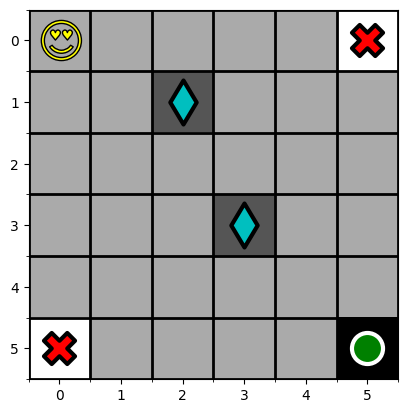

Current State: [[111.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 1
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


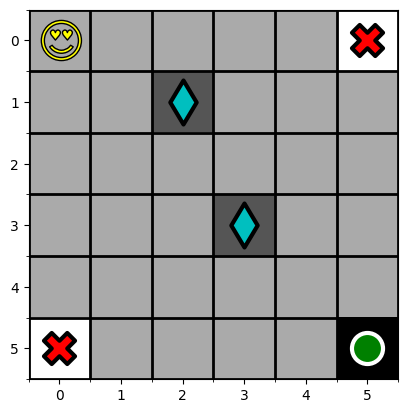

Current State: [[  0. 111.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 2
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


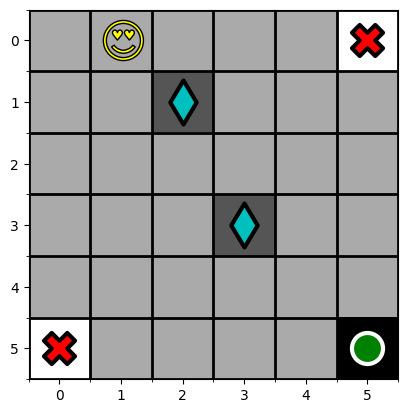

Current State: [[  0.   0. 111.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 2
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


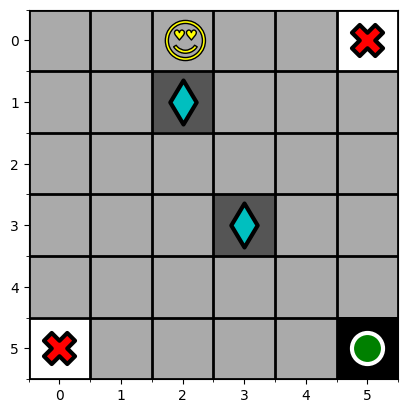

Current State: [[  0.   0. 111.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 1
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


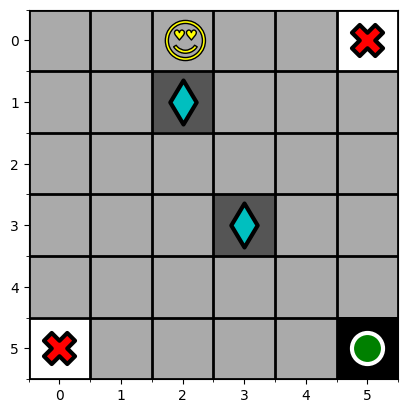

Current State: [[  0.   0. 111.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 1
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


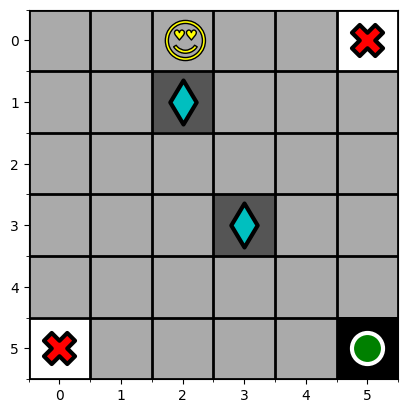

Current State: [[  0.   0.   0. 111.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 2
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


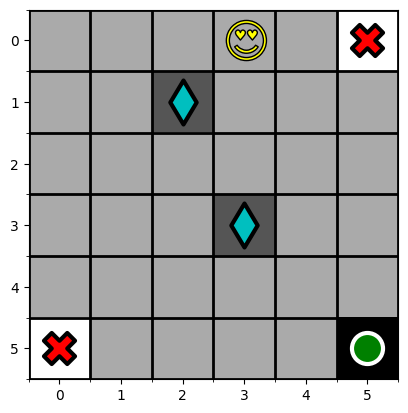

Current State: [[  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0. 111.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 0
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


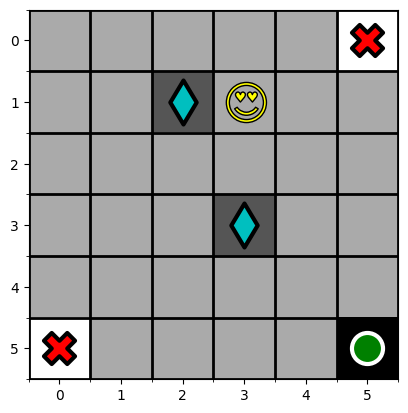

Current State: [[  0.   0.   0.   0.   0.   0.]
 [  0.   0. 111.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 3
Reward Gained: 1
Game Over: False
Agent is within the Grid: True


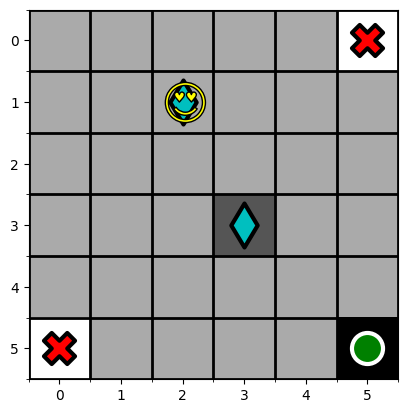

Current State: [[  0.   0.   0.   0.   0.   0.]
 [  0. 111.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 3
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


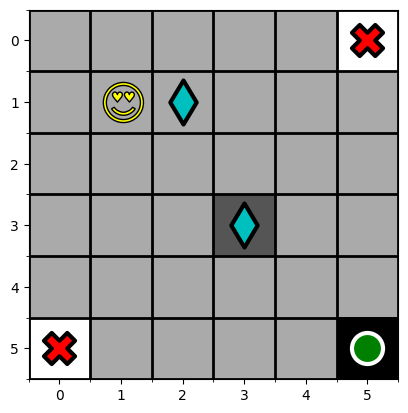

Current State: [[  0.   0.   0.   0.   0.   0.]
 [  0.   0. 111.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 2
Reward Gained: 1
Game Over: False
Agent is within the Grid: True


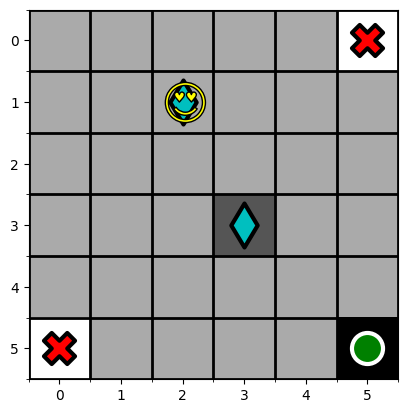

Current State: [[  0.   0.   0.   0.   0.   0.]
 [  0. 111.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 3
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


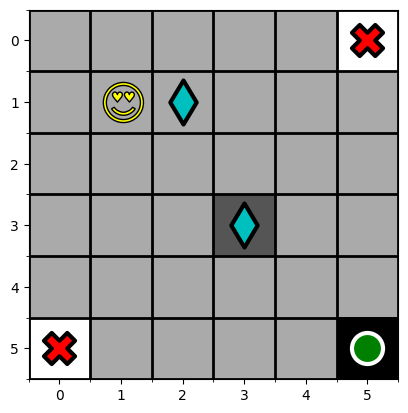

Current State: [[  0. 111.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 1
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


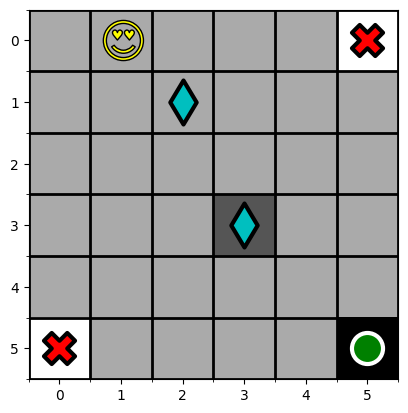

Current State: [[  0.   0.   0.   0.   0.   0.]
 [  0. 111.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 0
Reward Gained: 0
Game Over: False
Agent is within the Grid: True


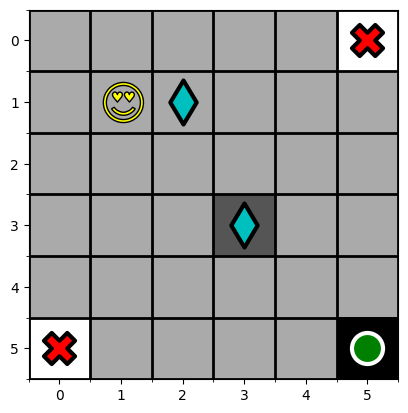

Current State: [[  0. 111.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0. 888.]]
Chosen Action: 1
Reward Gained: 0
Game Over: True
Agent is within the Grid: True
Sorry! You have reached the maximum timesteps


In [65]:
class Random_Agent_Action:
  def __init__(self, env):
    self.env = env
    self.observation_space = env.observation_space
    self.action_space = env.action_space
  def step(self, obs):
    return np.random.choice(self.action_space.n)

my_env = Deterministic_Environment()
user_agent = Random_Agent_Action(my_env)
terminated, truncated = False, False
obs, info = my_env.reset()
agent_actions = []
while not terminated:
    a_move = user_agent.step(obs)
    observation, reward, terminated, truncated = my_env.step(a_move)
    print("Chosen Action:", a_move)
    print("Reward Gained:", reward)
    print("Game Over:", terminated)
    print("Agent is within the Grid:", truncated)
    if terminated != True:
      agent_actions.append((my_env.agent_pos[0], my_env.agent_pos[1]))
      time.sleep(0.5)
      my_env.render(agent_actions)
    else:
      print("Sorry! You have reached the maximum timesteps")
      my_env.reset()

**1.2. Stochastic Environment**

In [ ]:
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import numpy as np
import time

In [ ]:
# Definition of the Grid Environment class.

class GridEnvironment(gym.Env):
    # Attribute of a Gym class that provides info about the render modes
    metadata = { 'render.modes': [] }

    # Initialization function
    def __init__(self):

      self.observation_space = spaces.Discrete(36)
      self.action_space = spaces.Discrete(4)
      self.max_timesteps = 5

      self.timestep = 0
      self.agent_pos = [0, 0]
      self.goal_pos = [2, 2]
      self.state = np.zeros((3,3))
      self.state[tuple(self.agent_pos)] = 1
      self.state[tuple(self.goal_pos)] = 0.5

    # Reset function
    def reset(self, **kwargs):
      self.state = np.zeros((3,3))
      self.state[tuple(self.agent_pos)] = 1
      self.state[tuple(self.goal_pos)] = 0.5
      observation = self.state.flatten()
      info = {}
      return observation, info

    # Step function: Contains the implementation for what happens when an
    # agent takes a step in the environment.
    def step(self, action):
      if action == 0: #down
        self.agent_pos[0] += 1
      if action == 1: #up
        self.agent_pos[0] -= 1
      if action == 2: #right
        self.agent_pos[1] += 1
      if action == 3: #left
        self.agent_pos[1] -= 1
      # Comment this to demonstrate the truncation condition.
      self.agent_pos = np.clip(self.agent_pos, 0, 2)

      self.state = np.zeros((3,3))
      self.state[tuple(self.agent_pos)] = 1
      self.state[tuple(self.goal_pos)] = 0.5
      observation = self.state.flatten()

      reward = 0
      if np.array_equal(self.agent_pos, self.goal_pos):
        reward = 1

      self.timestep += 1

      # Condition to check for termination (episode is over)
      terminated = True if self.timestep >= self.max_timesteps else False

      # Condition to check if agent is traversing to a cell beyond the permitted cells
      # This helps the agent to learn how to behave in a safe and predictable manner
      truncated = True if np.all((np.asarray(self.agent_pos) >=0 ) & (np.asarray(self.agent_pos) <= 2)) else False

      info = {}

      return observation, reward, terminated, truncated, info

    # Render function: Visualizes the environment
    def render(self):
      plt.title('Grid Environment')
      plt.imshow(self.state)

In [ ]:
# Definition an agent that takes action randomly
class RandomAgent:
  def __init__(self, env):
    self.env = env
    self.observation_space = env.observation_space
    self.action_space = env.action_space
  def step(self, obs):
    """Takes a step in the environment by choosing an action randomly.

    Args:
        obs: The current observation.

    Returns:
        The action to take.
    """
    return np.random.choice(self.action_space.n)

Current State: [1.  0.  0.  0.  0.  0.  0.  0.  0.5] Action chosen: 1 , Reward Gained: 0 , Game Over: False
Current State: [1.  0.  0.  0.  0.  0.  0.  0.  0.5] Action chosen: 1 , Reward Gained: 0 , Game Over: False
Current State: [1.  0.  0.  0.  0.  0.  0.  0.  0.5] Action chosen: 1 , Reward Gained: 0 , Game Over: False
Current State: [1.  0.  0.  0.  0.  0.  0.  0.  0.5] Action chosen: 3 , Reward Gained: 0 , Game Over: False
Current State: [0.  0.  0.  1.  0.  0.  0.  0.  0.5] Action chosen: 0 , Reward Gained: 0 , Game Over: True


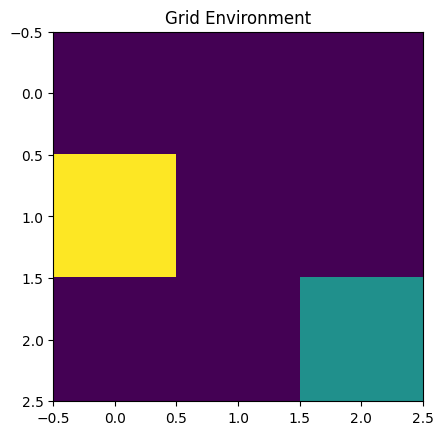

In [ ]:
# Sample code for environment and agent implementation. Also shows
# visualization of the random agent's movement across the grid. The yellow cell
# shows the movement of the agent.
if __name__ == '__main__':
  env = GridEnvironment()
  agent = RandomAgent(env)
  obs, info = env.reset()
  terminated, truncated = False, False
  while not terminated:
    action = agent.step(obs)
    obs, reward, terminated, truncated, info = env.step(action)
    print('Current State:',obs,'Action chosen:', action, ', Reward Gained:', reward, ', Game Over:', terminated)
    env.render()